In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from experiments.loader import load_generated

In [2]:
df = load_generated()
df.head()

,llm,mapping,crml,domain,requirement,attempt,model,api_calls,input_tokens,output_tokens,total_tokens,duration_s,tokens_per_s,cache_read_tokens,cache_write_tokens,tool_call_limit_exceeded,classification,detail
0,qwen3.5_27b,None,/home/ubuntu/crml/vol/CRML/LLM/generated/qwen3...,SRI,speed1,1,qwen3.5:27b,15,122288,8805,131093,271.859,32.4,None,None,False,CORRECT,NaN
1,qwen3.5_27b,None,/home/ubuntu/crml/vol/CRML/LLM/generated/qwen3...,SRI,speed1,2,qwen3.5:27b,13,94530,5611,100141,182.471,30.8,None,None,False,CORRECT,NaN
2,qwen3.5_27b,None,/home/ubuntu/crml/vol/CRML/LLM/generated/qwen3...,SRI,speed1,3,qwen3.5:27b,16,148185,5035,153220,176.879,28.5,None,None,False,CORRECT,NaN
3,qwen3.5_27b,None,/home/ubuntu/crml/vol/CRML/LLM/generated/qwen3...,SRI,speed1,4,qwen3.5:27b,11,52881,4991,57872,153.232,32.6,None,None,False,CORRECT,NaN
4,qwen3.5_27b,None,/home/ubuntu/crml/vol/CRML/LLM/generated/qwen3...,SRI,speed1,5,qwen3.5:27b,19,181565,9318,190883,295.666,31.5,None,None,False,COMPILATION,Built in operator undefined : integrate on Boo...


In [3]:
df[["llm", "domain", "requirement", "attempt", "classification", "detail"]].head(20)

,llm,domain,requirement,attempt,classification,detail
0,qwen3.5_27b,SRI,speed1,1,CORRECT,NaN
1,qwen3.5_27b,SRI,speed1,2,CORRECT,NaN
2,qwen3.5_27b,SRI,speed1,3,CORRECT,NaN
3,qwen3.5_27b,SRI,speed1,4,CORRECT,NaN
4,qwen3.5_27b,SRI,speed1,5,COMPILATION,Built in operator undefined : integrate on Boo...
5,qwen3.5_27b,SRI,temp1,1,COMPILATION,Built in operator undefined : integrate on Boo...
6,qwen3.5_27b,SRI,temp1,2,CORRECT,NaN
7,qwen3.5_27b,SRI,temp1,3,CORRECT,NaN
8,qwen3.5_27b,SRI,temp1,4,CORRECT,NaN
9,qwen3.5_27b,SRI,temp1,5,CORRECT,NaN


## RQ1

/tmp/ipykernel_33108/3522765329.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cls["req_label"] = df_cls["domain"] + "\n" + df_cls["requirement"]


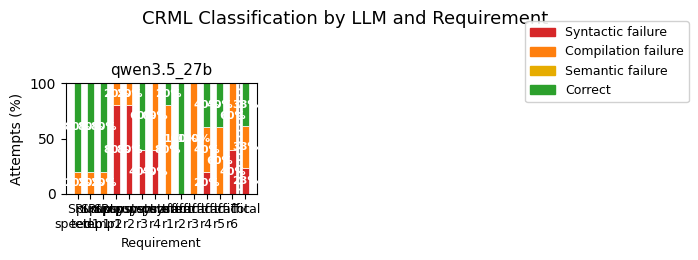

In [4]:
import numpy as np
import matplotlib.patches as mpatches

CAT_ORDER  = ["SYNTAX", "COMPILATION", "LOAD", "CORRECT"]
CAT_LABELS = {
    "SYNTAX":      "Syntactic failure",
    "COMPILATION": "Compilation failure",
    "LOAD":        "Semantic failure",
    "CORRECT":     "Correct",
}
CAT_COLORS = {
    "SYNTAX":      "#d62728",
    "COMPILATION": "#ff7f0e",
    "LOAD":        "#e6ac00",
    "CORRECT":     "#2ca02c",
}

MAX_LLMS = 3
all_llms = sorted(df["llm"].unique())

df_cls = df.dropna(subset=["classification"]).copy()
df_cls["req_label"] = df_cls["domain"] + "\n" + df_cls["requirement"]

fig, axes = plt.subplots(1, MAX_LLMS, figsize=(7, 2.5), sharey=True)

for ax, llm in zip(axes, all_llms):
    sub = df_cls[df_cls["llm"] == llm]
    req_labels = sorted(sub["req_label"].unique())
    col_labels = req_labels + ["Total"]

    counts = {
        lbl: {cat: (sub[sub["req_label"] == lbl]["classification"] == cat).sum()
              for cat in CAT_ORDER}
        for lbl in req_labels
    }
    counts["Total"] = {cat: (sub["classification"] == cat).sum() for cat in CAT_ORDER}

    # Normalise each column to 100 %
    totals = {lbl: sum(counts[lbl].values()) for lbl in col_labels}
    pct = {
        lbl: {cat: 100 * counts[lbl][cat] / totals[lbl] if totals[lbl] else 0
              for cat in CAT_ORDER}
        for lbl in col_labels
    }

    x = np.arange(len(col_labels))
    bottom = np.zeros(len(col_labels))

    for cat in CAT_ORDER:
        vals = np.array([pct[lbl][cat] for lbl in col_labels])
        bars = ax.bar(x, vals, bottom=bottom, color=CAT_COLORS[cat], width=0.5,
                      edgecolor="white", linewidth=0.5)
        for rect, v, b in zip(bars, vals, bottom):
            if v >= 5:
                ax.text(rect.get_x() + rect.get_width() / 2,
                        b + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        bottom += vals

    ax.axvline(len(req_labels) - 0.5, color="grey", linewidth=0.8, linestyle="--")
    ax.set_ylim(0, 100)
    ax.set_title(llm, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_xlabel("Requirement", fontsize=9)

axes[0].set_ylabel("Attempts (%)", fontsize=10)

for ax in axes[len(all_llms):]:
    ax.set_visible(False)

handles = [mpatches.Patch(color=CAT_COLORS[c], label=CAT_LABELS[c]) for c in CAT_ORDER]
fig.legend(handles=handles, loc="upper right", fontsize=9,
           bbox_to_anchor=(1.0, 1.0), framealpha=0.9)

fig.suptitle("CRML Classification by LLM and Requirement", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures_classification.pdf", bbox_inches="tight")
plt.show()


In [5]:
from math import comb as _comb
from experiments.tests import TESTS as _TESTS

K_VAL = 5

CAT_ORDER  = ["SYNTAX", "COMPILATION", "LOAD", "CORRECT"]
CAT_SHORT  = {"SYNTAX": "Syn.", "COMPILATION": "Comp.", "LOAD": "Sem.", "CORRECT": "Cor."}

DOMAIN_ORDER  = ["SRI", "traffic", "pumpsystem"]
DOMAIN_LABELS = {"SRI": "SRI", "traffic": "Traffic", "pumpsystem": "Pump system"}
REQ_ORDER = {d: [r["id"] for r in _TESTS[d]["requirements"]] for d in DOMAIN_ORDER}

def _pass_at_k(n, c, k=K_VAL):
    if n == 0:
        return float("nan")
    if n < k:
        return 1.0 if c > 0 else 0.0
    return 1.0 - _comb(n - c, k) / _comb(n, k)

df_cls = df.dropna(subset=["classification"]).copy()
all_llms = sorted(df_cls["llm"].unique())

# Count per (domain, requirement, llm, classification)
_counts = (
    df_cls
    .groupby(["domain", "requirement", "llm", "classification"])
    .size()
    .unstack("classification", fill_value=0)
    .reindex(columns=CAT_ORDER, fill_value=0)
    .reset_index()
)
_counts["_total"] = _counts[CAT_ORDER].sum(axis=1)
_counts["_pass5"] = _counts.apply(
    lambda r: _pass_at_k(int(r["_total"]), int(r["CORRECT"])), axis=1
)

# ── LaTeX builder ─────────────────────────────────────────────────────────────
COLS_PER_LLM = len(CAT_ORDER)        # 4 cats only; pass@5 goes in summary row under Cor.

def _row_data(domain, req, llm):
    sub = _counts[
        (_counts["domain"] == domain) &
        (_counts["requirement"] == req) &
        (_counts["llm"] == llm)
    ]
    if sub.empty:
        return None
    return sub.iloc[0]

# Column spec:  ll | cccc | cccc | ...
col_spec = "ll" + "".join("|" + "c" * COLS_PER_LLM for _ in all_llms)

lines = []
lines.append(r"\begin{tabular}{" + col_spec + "}")
lines.append(r"\toprule")

# ── LLM header row ──
llm_header = ["", ""]
for llm in all_llms:
    llm_header.append(
        r"\multicolumn{" + str(COLS_PER_LLM) + r"}{c}{"
        + llm.replace("_", r"\_") + "}"
    )
lines.append(" & ".join(llm_header) + r" \\")

# cmidrules under each LLM span
cmid = ""
for i in range(len(all_llms)):
    lo = 3 + i * COLS_PER_LLM
    hi = lo + COLS_PER_LLM - 1
    cmid += r"\cmidrule(lr){" + f"{lo}-{hi}" + "}"
lines.append(cmid)

# ── Sub-header ──
sub_header = ["Domain", "Req."]
for _ in all_llms:
    for cat in CAT_ORDER:
        sub_header.append(CAT_SHORT[cat])
lines.append(" & ".join(sub_header) + r" \\")
lines.append(r"\midrule")

# ── Domain groups ──
for domain in DOMAIN_ORDER:
    reqs = REQ_ORDER[domain]
    total_cols = 2 + len(all_llms) * COLS_PER_LLM
    lines.append(
        r"\multicolumn{" + str(total_cols) + r"}{l}{\textit{"
        + DOMAIN_LABELS[domain] + r"}} \\"
    )
    for req in reqs:
        row = ["", req]
        for llm in all_llms:
            rd = _row_data(domain, req, llm)
            if rd is None:
                row.extend(["--"] * COLS_PER_LLM)
            else:
                for cat in CAT_ORDER:
                    row.append(str(int(rd[cat])))
        lines.append(" & ".join(row) + r" \\")
    lines.append(r"\midrule")

# ── Summary pass@5 row — value placed under Cor. (last column of each LLM group) ──
summary = [r"\textbf{pass@5}", ""]
for llm in all_llms:
    llm_data = _counts[_counts["llm"] == llm]
    agg = llm_data["_pass5"].mean()
    summary.extend([""] * (len(CAT_ORDER) - 1))
    summary.append("--" if agg != agg else f"{agg:.2f}")
lines.append(" & ".join(summary) + r" \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")

latex_table = "\n".join(lines)
print(latex_table)


\begin{tabular}{ll|cccc}
\toprule
 &  & \multicolumn{4}{c}{qwen3.5\_27b} \\
\cmidrule(lr){3-6}
Domain & Req. & Syn. & Comp. & Sem. & Cor. \\
\midrule
\multicolumn{6}{l}{\textit{SRI}} \\
 & temp1 & 0 & 1 & 0 & 4 \\
 & temp2 & 0 & 1 & 0 & 4 \\
 & speed1 & 0 & 1 & 0 & 4 \\
\midrule
\multicolumn{6}{l}{\textit{Traffic}} \\
 & r1 & 0 & 4 & 0 & 1 \\
 & r2 & 0 & 0 & 0 & 5 \\
 & r3 & 0 & 5 & 0 & 0 \\
 & r4 & 1 & 2 & 0 & 2 \\
 & r5 & 0 & 3 & 0 & 2 \\
 & r6 & 2 & 3 & 0 & 0 \\
\midrule
\multicolumn{6}{l}{\textit{Pump system}} \\
 & r1 & 4 & 1 & 0 & 0 \\
 & r2 & 4 & 1 & 0 & 0 \\
 & r3 & 2 & 0 & 0 & 3 \\
 & r4 & 2 & 3 & 0 & 0 \\
\midrule
\textbf{pass@5} &  &  &  &  & 0.62 \\
\bottomrule
\end{tabular}


## RQ2

/tmp/ipykernel_33108/368308537.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_rq2["tool_calls"] = df_rq2["api_calls"] - USER_CALLS
/tmp/ipykernel_33108/368308537.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in p

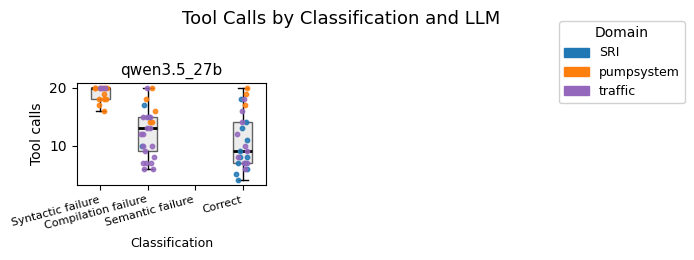

In [6]:
rng = np.random.default_rng(42)

# Tool calls = total api_calls minus the deterministic user calls (1 + n, n=1 per attempt)
USER_CALLS = 2
df_rq2 = df.dropna(subset=["classification", "api_calls"]).copy()
df_rq2["tool_calls"] = df_rq2["api_calls"] - USER_CALLS
df_rq2["req_label"] = df_rq2["domain"] + " " + df_rq2["requirement"]

req_labels = sorted(df_rq2["req_label"].unique())
domains = sorted(df_rq2["domain"].unique())
DOMAIN_COLORS = dict(zip(domains, ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c"]))
REQ_COLORS = {req: DOMAIN_COLORS[req.split(" ")[0]] for req in req_labels}

# X positions follow severity order defined in RQ1
X_LABELS = [CAT_LABELS[c] for c in CAT_ORDER]

fig, axes = plt.subplots(1, MAX_LLMS, figsize=(7, 2.5), sharey=True)

for ax, llm in zip(axes, all_llms):
    sub = df_rq2[df_rq2["llm"] == llm]

    # Box plot (grey, no outlier markers — individual points shown instead)
    box_data = [sub[sub["classification"] == cat]["tool_calls"].values for cat in CAT_ORDER]
    ax.boxplot(box_data, positions=range(len(CAT_ORDER)), widths=0.4,
               patch_artist=True,
               boxprops=dict(facecolor="#e0e0e0", alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               whiskerprops=dict(linewidth=1),
               capprops=dict(linewidth=1),
               flierprops=dict(marker=""))

    # Strip plot — jittered individual points coloured by domain
    for i, cat in enumerate(CAT_ORDER):
        cat_sub = sub[sub["classification"] == cat]
        for req in req_labels:
            vals = cat_sub[cat_sub["req_label"] == req]["tool_calls"].values
            if len(vals) == 0:
                continue
            jitter = rng.uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(i + jitter, vals, color=REQ_COLORS[req],
                       s=10, alpha=0.85, zorder=3)

    ax.set_xticks(range(len(CAT_ORDER)))
    ax.set_xticklabels(X_LABELS, fontsize=8, rotation=15, ha="right")
    ax.set_title(llm, fontsize=11)
    ax.set_xlabel("Classification", fontsize=9)

axes[0].set_ylabel("Tool calls", fontsize=10)

for ax in axes[len(all_llms):]:
    ax.set_visible(False)

domain_handles = [mpatches.Patch(color=DOMAIN_COLORS[d], label=d) for d in domains]
fig.legend(handles=domain_handles, title="Domain", loc="upper right",
           fontsize=9, bbox_to_anchor=(1.0, 1.0), framealpha=0.9)

fig.suptitle("Tool Calls by Classification and LLM", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures_tool_calls.pdf", bbox_inches="tight")
plt.show()


In [7]:
# ── LaTeX \newcommand definitions for tool-call statistics ───────────────────
# Indexed by LLM × domain × classification result
# Usage example: "correct attempts on SRI used \QwenSriCorrectMean{} tool calls on average"
LLM_MACRO = {
    "qwen3.5_27b": "Qwen",
    "claude":      "Claude",
    "openai":      "GPT",
}
DOMAIN_MACRO = {
    "SRI":        "Sri",
    "traffic":    "Traffic",
    "pumpsystem": "Pumpsystem",
}
CLS_MACRO = {
    "SYNTAX":      "Syntax",
    "COMPILATION": "Compilation",
    "LOAD":        "Load",
    "CORRECT":     "Correct",
}
STAT_FNS = [
    ("Mean",   np.mean),
    ("Median", np.median),
    ("Min",    np.min),
    ("Max",    np.max),
]
def _fmt_toolcalls(x):
    return f"{x:.1f}"

cmds_tc = []

for llm in sorted(df_rq2["llm"].unique()):
    sub     = df_rq2[df_rq2["llm"] == llm]
    llm_tag = LLM_MACRO.get(llm, llm.replace("_", "").replace(".", ""))

    dom_groups = (
        [(DOMAIN_MACRO[d], sub[sub["domain"] == d]) for d in DOMAIN_ORDER]
        + [("All", sub)]
    )

    for dom_tag, dom_data in dom_groups:
        for cls, cls_tag in CLS_MACRO.items():
            vals = dom_data[dom_data["classification"] == cls]["tool_calls"].dropna().values
            if len(vals) == 0:
                continue
            for stat_tag, fn in STAT_FNS:
                cmd = f"\\{llm_tag}{dom_tag}{cls_tag}{stat_tag}"
                cmds_tc.append(f"\\newcommand{{{cmd}}}{{{_fmt_toolcalls(fn(vals))}}}")
        cmds_tc.append("")

print("\n".join(cmds_tc))


\newcommand{\QwenSriCompilationMean}{14.0}
\newcommand{\QwenSriCompilationMedian}{15.0}
\newcommand{\QwenSriCompilationMin}{10.0}
\newcommand{\QwenSriCompilationMax}{17.0}
\newcommand{\QwenSriCorrectMean}{9.2}
\newcommand{\QwenSriCorrectMedian}{8.0}
\newcommand{\QwenSriCorrectMin}{4.0}
\newcommand{\QwenSriCorrectMax}{18.0}

\newcommand{\QwenTrafficSyntaxMean}{20.0}
\newcommand{\QwenTrafficSyntaxMedian}{20.0}
\newcommand{\QwenTrafficSyntaxMin}{20.0}
\newcommand{\QwenTrafficSyntaxMax}{20.0}
\newcommand{\QwenTrafficCompilationMean}{10.9}
\newcommand{\QwenTrafficCompilationMedian}{10.0}
\newcommand{\QwenTrafficCompilationMin}{6.0}
\newcommand{\QwenTrafficCompilationMax}{20.0}
\newcommand{\QwenTrafficCorrectMean}{10.7}
\newcommand{\QwenTrafficCorrectMedian}{9.5}
\newcommand{\QwenTrafficCorrectMin}{6.0}
\newcommand{\QwenTrafficCorrectMax}{18.0}

\newcommand{\QwenPumpsystemSyntaxMean}{18.8}
\newcommand{\QwenPumpsystemSyntaxMedian}{19.5}
\newcommand{\QwenPumpsystemSyntaxMin}{16.0}
\newcommand{

## RQ3

/tmp/ipykernel_33108/1108102274.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_rq3["cache_read"]    = df_rq3["cache_read_tokens"].fillna(0)
/tmp/ipykernel_33108/1108102274.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignme

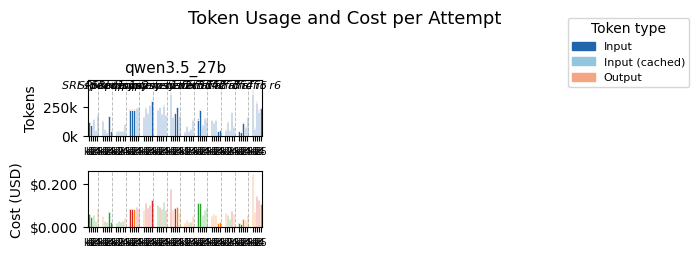

In [8]:
# ── Pricing table  ($/M tokens) ─────────────────────────────────────────────
PRICES = {
    "claude":      {"input": 3.00, "cache_read": 0.30, "output": 15.00},
    "openai":      {"input": 2.50, "cache_read": 1.25, "output": 10.00},
    "qwen3.5_27b": {"input": 0.29, "cache_read": 0.00, "output":  3.20},  # local
}

# ── Derived columns ──────────────────────────────────────────────────────────
df_rq3 = df.dropna(subset=["input_tokens", "output_tokens"]).copy()
df_rq3["cache_read"]    = df_rq3["cache_read_tokens"].fillna(0)
df_rq3["regular_input"] = df_rq3["input_tokens"] - df_rq3["cache_read"]
df_rq3["req_label"]     = df_rq3["domain"] + " " + df_rq3["requirement"]

def _cost(row):
    p = PRICES.get(row["llm"], {"input": 0, "cache_read": 0, "output": 0})
    return (row["regular_input"]  * p["input"]
            + row["cache_read"]   * p["cache_read"]
            + row["output_tokens"]* p["output"]) / 1e6

df_rq3["cost_usd"] = df_rq3.apply(_cost, axis=1)

# ── Layout helpers ───────────────────────────────────────────────────────────
TOK_SEGS   = ["regular_input", "cache_read", "output_tokens"]
TOK_COLORS = {"regular_input": "#2166ac", "cache_read": "#92c5de", "output_tokens": "#f4a582"}
TOK_LABELS = {"regular_input": "Input", "cache_read": "Input (cached)", "output_tokens": "Output"}
GAP = 1.5   # blank x-units between requirement groups

def _x_layout(sub):
    """Return (xs, tick_labels, {req_label: centre_x})."""
    xs, labs, centres = [], [], {}
    x = 0.0
    for req in sorted(sub["req_label"].unique()):
        grp = sub[sub["req_label"] == req].sort_values("attempt")
        start = x
        for _, row in grp.iterrows():
            xs.append(x)
            labs.append(f"k{int(row['attempt'])}")
            x += 1
        centres[req] = (start + x - 1) / 2
        x += GAP
    return xs, labs, centres

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, MAX_LLMS, figsize=(7, 2.5))

for col, llm in enumerate(all_llms):
    sub = df_rq3[df_rq3["llm"] == llm].sort_values(["req_label", "attempt"]).reset_index(drop=True)
    xs, x_labs, centres = _x_layout(sub)
    ax_tok  = axes[0][col]
    ax_cost = axes[1][col]

    # ── Row 0: stacked token bars ──
    bottom = np.zeros(len(sub))
    for seg in TOK_SEGS:
        vals = sub[seg].values.astype(float)
        ax_tok.bar(xs, vals, bottom=bottom, color=TOK_COLORS[seg], width=0.6,
                   label=TOK_LABELS[seg], edgecolor="white", linewidth=0.4)
        bottom += vals

    ax_tok.set_title(llm, fontsize=11)
    ax_tok.set_xticks(xs)
    ax_tok.set_xticklabels(x_labs, fontsize=7)
    ax_tok.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
    ax_tok.set_xlim(-0.7, max(xs) + 0.7)

    # Requirement group labels above the bars
    ax_tok.set_ylim(0, ax_tok.get_ylim()[1] * 1.12)
    for req, cx in centres.items():
        ax_tok.text(cx, ax_tok.get_ylim()[1] * 0.99, req,
                    ha="center", va="top", fontsize=8, style="italic")

    # ── Row 1: cost bars coloured by classification ──
    bar_colors = [CAT_COLORS.get(c, "#aaaaaa") if pd.notna(c) else "#aaaaaa"
                  for c in sub.get("classification", pd.Series([""] * len(sub)))]
    ax_cost.bar(xs, sub["cost_usd"].values, color=bar_colors,
                width=0.6, edgecolor="white", linewidth=0.4)
    ax_cost.set_xticks(xs)
    ax_cost.set_xticklabels(x_labs, fontsize=7)
    ax_cost.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.3f}"))
    ax_cost.set_xlim(-0.7, max(xs) + 0.7)

    # Dashed separators between requirement groups
    gap_xs = [xs[i] + 0.5 for i in range(len(xs) - 1) if xs[i + 1] - xs[i] > 1]
    for gx in gap_xs:
        ax_tok.axvline( gx, color="grey", linewidth=0.7, linestyle="--", alpha=0.5)
        ax_cost.axvline(gx, color="grey", linewidth=0.7, linestyle="--", alpha=0.5)

axes[0][0].set_ylabel("Tokens", fontsize=10)
axes[1][0].set_ylabel("Cost (USD)", fontsize=10)

for col in range(len(all_llms), MAX_LLMS):
    axes[0][col].set_visible(False)
    axes[1][col].set_visible(False)

tok_handles = [mpatches.Patch(color=TOK_COLORS[s], label=TOK_LABELS[s]) for s in TOK_SEGS]
fig.legend(handles=tok_handles, title="Token type", loc="upper right",
           fontsize=8, bbox_to_anchor=(1.0, 1.0))

fig.suptitle("Token Usage and Cost per Attempt", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures_cost.pdf", bbox_inches="tight")
plt.show()


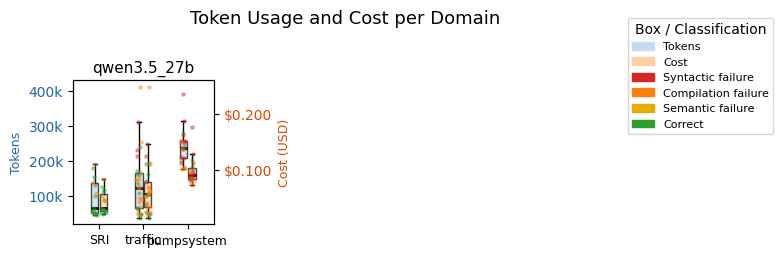

In [9]:
# ── Figure: 1 row × MAX_LLMS — paired token/cost scatter, aggregated by domain ──
# Left sub-position per domain = tokens, right = cost.
OFFSET = 0.10
DOMAIN_ORDER_PLOT = ["SRI", "traffic", "pumpsystem"]

fig, axes = plt.subplots(1, MAX_LLMS, figsize=(7, 2.5))

for col, llm in enumerate(all_llms):
    sub = df_rq3[df_rq3["llm"] == llm].copy()

    ax  = axes[col]
    ax2 = ax.twinx()

    for xi, domain in enumerate(DOMAIN_ORDER_PLOT):
        dom = sub[sub["domain"] == domain].reset_index(drop=True)
        if dom.empty:
            continue
        jitters = rng.uniform(-0.06, 0.06, size=len(dom))

        ax.boxplot(dom["total_tokens"].values,
                   positions=[xi - OFFSET], widths=0.16, patch_artist=True,
                   boxprops=dict(facecolor="#c6dbef", alpha=0.7),
                   medianprops=dict(color="black", linewidth=2),
                   whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
                   flierprops=dict(marker=""))

        ax2.boxplot(dom["cost_usd"].values,
                    positions=[xi + OFFSET], widths=0.16, patch_artist=True,
                    boxprops=dict(facecolor="#fdd0a2", alpha=0.7),
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
                    flierprops=dict(marker=""))

        for j in range(len(dom)):
            c     = dom.loc[j, "classification"]
            color = CAT_COLORS.get(c, "#aaaaaa") if pd.notna(c) else "#aaaaaa"
            ax.scatter( xi - OFFSET + jitters[j], dom.loc[j, "total_tokens"],
                        color=color, s=5, alpha=0.4, zorder=3)
            ax2.scatter(xi + OFFSET + jitters[j], dom.loc[j, "cost_usd"],
                        color=color, s=5, alpha=0.4, zorder=3)

    ax.set_xlim(-0.6, len(DOMAIN_ORDER_PLOT) - 0.4)
    ax.set_xticks(range(len(DOMAIN_ORDER_PLOT)))
    ax.set_xticklabels(DOMAIN_ORDER_PLOT, fontsize=9)
    ax.set_title(llm, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
    ax.set_ylabel("Tokens", fontsize=9, color="#2166ac")
    ax.tick_params(axis="y", labelcolor="#2166ac")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.3f}"))
    ax2.set_ylabel("Cost (USD)", fontsize=9, color="#d94801")
    ax2.tick_params(axis="y", labelcolor="#d94801")
    ax2.grid(False)

for col in range(len(all_llms), MAX_LLMS):
    axes[col].set_visible(False)

box_handles = [
    mpatches.Patch(color="#c6dbef", label="Tokens"),
    mpatches.Patch(color="#fdd0a2", label="Cost"),
]
cls_handles = [mpatches.Patch(color=CAT_COLORS[c], label=CAT_LABELS[c]) for c in CAT_ORDER]
fig.legend(handles=box_handles + cls_handles, loc="upper right",
           fontsize=8, bbox_to_anchor=(1.12, 1.0),
           title="Box / Classification")

fig.suptitle("Token Usage and Cost per Domain", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures_cost_scatter.pdf", bbox_inches="tight")
plt.show()


In [10]:
# ── LaTeX \newcommand definitions for token/cost statistics ──────────────────
# Usage example: "the mean token count for SRI was \QwenSriTokensMean"

LLM_MACRO = {
    "qwen3.5_27b": "Qwen",
    "claude":      "Claude",
    "openai":      "GPT",
}
DOMAIN_MACRO = {
    "SRI":        "Sri",
    "traffic":    "Traffic",
    "pumpsystem": "Pumpsystem",
}

def _fmt_tokens(x):
    return f"{int(round(x)):,}".replace(",", "{,}")

def _fmt_cost(x):
    return f"{x:.4f}"

STAT_FNS = [
    ("Mean",   np.mean),
    ("Median", np.median),
    ("Min",    np.min),
    ("Max",    np.max),
]

cmds = []

for llm in sorted(df_rq3["llm"].unique()):
    sub     = df_rq3[df_rq3["llm"] == llm]
    llm_tag = LLM_MACRO.get(llm, llm.replace("_", "").replace(".", ""))

    groups = (
        [(DOMAIN_MACRO[d], sub[sub["domain"] == d]) for d in DOMAIN_ORDER_PLOT]
        + [("All", sub)]
    )

    for dom_tag, data in groups:
        for metric_tag, col, fmt in [
            ("Tokens", "total_tokens", _fmt_tokens),
            ("Cost",   "cost_usd",     _fmt_cost),
        ]:
            vals = data[col].dropna().values
            if len(vals) == 0:
                continue
            for stat_tag, fn in STAT_FNS:
                cmd = f"\\{llm_tag}{dom_tag}{metric_tag}{stat_tag}"
                cmds.append(f"\\newcommand{{{cmd}}}{{{fmt(fn(vals))}}}")
        cmds.append("")

print("\n".join(cmds))


\newcommand{\QwenSriTokensMean}{94{,}992}
\newcommand{\QwenSriTokensMedian}{64{,}991}
\newcommand{\QwenSriTokensMin}{44{,}817}
\newcommand{\QwenSriTokensMax}{190{,}883}
\newcommand{\QwenSriCostMean}{0.0417}
\newcommand{\QwenSriCostMedian}{0.0313}
\newcommand{\QwenSriCostMin}{0.0214}
\newcommand{\QwenSriCostMax}{0.0825}

\newcommand{\QwenTrafficTokensMean}{136{,}130}
\newcommand{\QwenTrafficTokensMedian}{123{,}612}
\newcommand{\QwenTrafficTokensMin}{37{,}476}
\newcommand{\QwenTrafficTokensMax}{410{,}791}
\newcommand{\QwenTrafficCostMean}{0.0660}
\newcommand{\QwenTrafficCostMedian}{0.0570}
\newcommand{\QwenTrafficCostMin}{0.0140}
\newcommand{\QwenTrafficCostMax}{0.2477}

\newcommand{\QwenPumpsystemTokensMean}{241{,}501}
\newcommand{\QwenPumpsystemTokensMedian}{237{,}607}
\newcommand{\QwenPumpsystemTokensMin}{176{,}221}
\newcommand{\QwenPumpsystemTokensMax}{389{,}704}
\newcommand{\QwenPumpsystemCostMean}{0.0968}
\newcommand{\QwenPumpsystemCostMedian}{0.0896}
\newcommand{\QwenPumpsystemCos

## Random stuff

In [11]:
# Sum total_tokens across attempts for each (llm, domain, requirement)
agg = (
    df.groupby(["llm", "domain", "requirement"], as_index=False)["total_tokens"]
    .sum()
)
agg

,llm,domain,requirement,total_tokens
0,qwen3.5_27b,SRI,speed1,633209
1,qwen3.5_27b,SRI,temp1,481690
2,qwen3.5_27b,SRI,temp2,309975
3,qwen3.5_27b,pumpsystem,r1,1209896
4,qwen3.5_27b,pumpsystem,r2,1233204
5,qwen3.5_27b,pumpsystem,r3,1170189
6,qwen3.5_27b,pumpsystem,r4,1216729
7,qwen3.5_27b,traffic,r1,398842
8,qwen3.5_27b,traffic,r2,839759
9,qwen3.5_27b,traffic,r3,521903


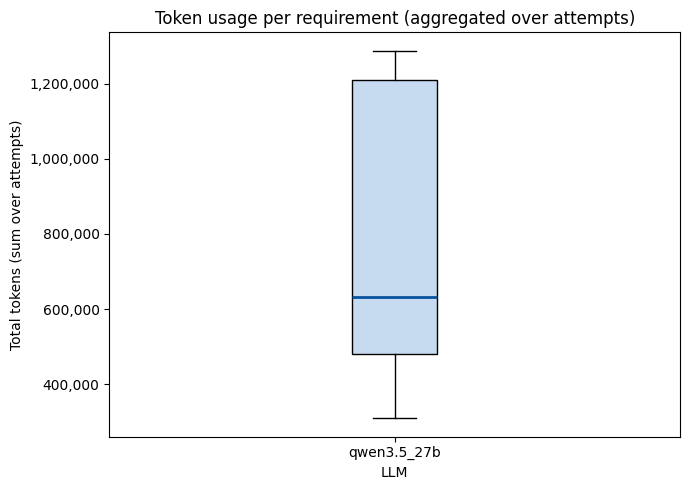

In [12]:
llms = sorted(agg["llm"].unique())
data = [agg.loc[agg["llm"] == llm, "total_tokens"].values for llm in llms]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(data, tick_labels=llms, patch_artist=True,
           boxprops=dict(facecolor="#c6dbef"),
           medianprops=dict(color="#08519c", linewidth=2))

ax.set_ylabel("Total tokens (sum over attempts)")
ax.set_xlabel("LLM")
ax.set_title("Token usage per requirement (aggregated over attempts)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("figures_total_tokens.pdf", bbox_inches="tight")
plt.show()

## Tool Use vs Correctness

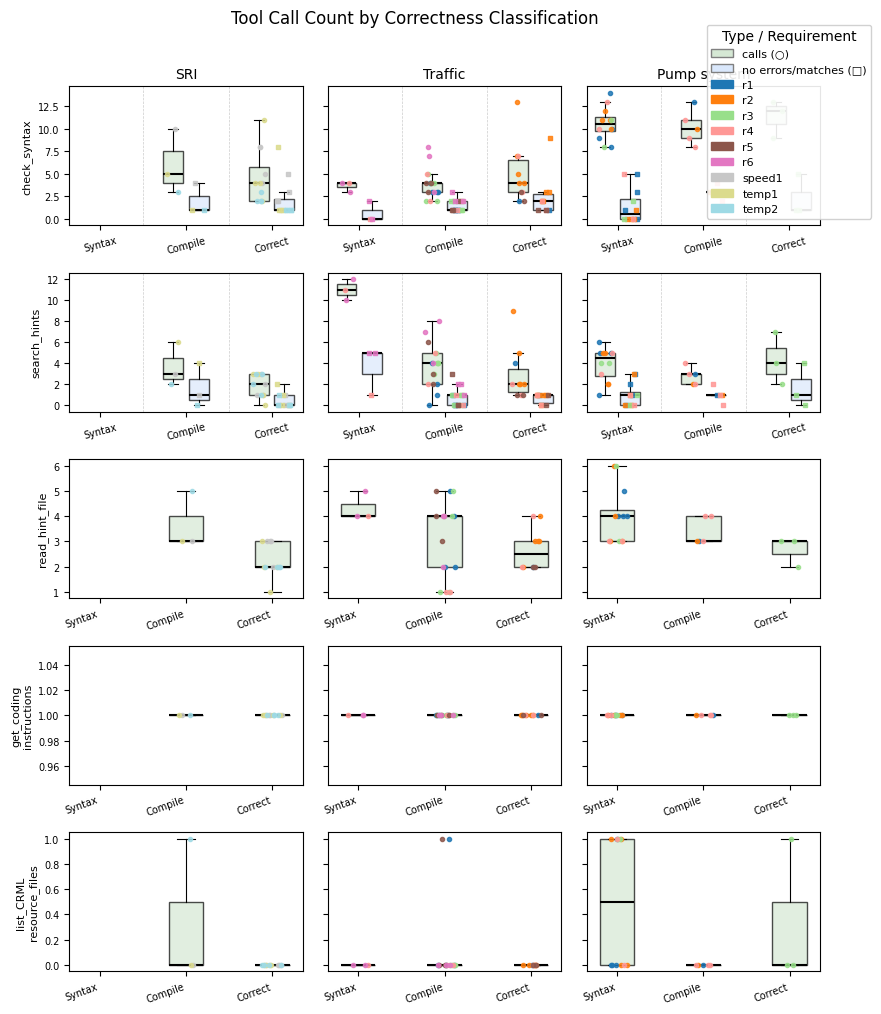

In [13]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from experiments.processing.tooluse import parse_log_file, merge_log_dataframes

# ── Load tool-use data and merge with classification results ──────────────────
_tu_raw = merge_log_dataframes([
    parse_log_file(p) for p in sorted(Path("generated").glob("**/*.log"))
])
_tu = (
    _tu_raw
    .assign(attempt=_tu_raw["shot_number"].str[1:].astype(int))
    .rename(columns={"model": "llm", "requirement_id": "requirement"})
    .drop(columns=["shot_number"])
)
df_tu = df[["llm", "domain", "requirement", "attempt", "classification"]].merge(
    _tu, on=["llm", "domain", "requirement", "attempt"], how="inner",
)

# ── Constants ─────────────────────────────────────────────────────────────────
_CAT_ORDER  = ["SYNTAX", "COMPILATION", "CORRECT"]   # Semantic / LOAD omitted
_CAT_LABELS = {"SYNTAX": "Syntax", "COMPILATION": "Compile", "CORRECT": "Correct"}

_DOMAIN_ORDER  = ["SRI", "traffic", "pumpsystem"]
_DOMAIN_LABELS = {"SRI": "SRI", "traffic": "Traffic", "pumpsystem": "Pump system"}

# Endpoint rows: (main_ep, secondary_ep or None).
# Paired endpoints share one subplot; secondary boxes sit beside the main boxes.
_ENDPOINT_GROUPS = [
    ("check_syntax",           "check_syntax_no_errors"),
    ("search_hints",           "search_hints_no_matches"),
    ("read_hint_file",         None),
    ("get_coding_instructions",None),
    ("list_CRML_resource_files", None),
]
PLOT_GROUPS = [(a, b) for a, b in _ENDPOINT_GROUPS if a in df_tu.columns]

_ROW_LABELS = {
    "check_syntax":            "check_syntax",
    "search_hints":            "search_hints",
    "read_hint_file":          "read_hint_file",
    "get_coding_instructions": "get_coding\ninstructions",
    "list_CRML_resource_files":"list_CRML\nresource_files",
}

# Box face colours: main vs. derived/special
_BOX_MAIN = "#d5e8d4"
_BOX_SEC  = "#dae8fc"

# Requirement colour palette
_all_reqs   = sorted(df_tu["requirement"].unique())
_req_colors = plt.cm.tab20(np.linspace(0, 1, max(len(_all_reqs), 1)))
REQ_PALETTE = dict(zip(_all_reqs, _req_colors))

_rng = np.random.default_rng(0)


# ── Utility ───────────────────────────────────────────────────────────────────
def _group_panel(ax, data, ep_main, ep2=None, *, ylabel=True):
    """Box + jittered strip for one (endpoint-group, domain) panel.

    Paired mode (ep2 given): the two endpoints share the panel.
      - Categories are spaced 1.5 units apart so their pair of boxes sits
        visibly separated from the neighbouring category.
      - Within each category the main box (○ scatter) sits to the left,
        the derived box (□ scatter) to the right.
    Single mode: standard layout, one box per category.
    """
    n = len(_CAT_ORDER)
    paired = ep2 is not None

    CAT_GAP = 1.5 if paired else 1.0
    BOX_OFF = 0.22 if paired else 0.0
    BOX_W   = 0.35 if paired else 0.40

    centers  = [i * CAT_GAP for i in range(n)]
    pos_main = [c - BOX_OFF for c in centers]
    pos_sec  = [c + BOX_OFF for c in centers] if paired else None

    def _bplot(positions, series_list, color):
        ax.boxplot(
            series_list, positions=positions, widths=BOX_W,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.7),
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            flierprops=dict(marker=""),
        )

    _bplot(pos_main,
           [data.loc[data["classification"] == c, ep_main].dropna().values for c in _CAT_ORDER],
           _BOX_MAIN)
    if paired:
        _bplot(pos_sec,
               [data.loc[data["classification"] == c, ep2].dropna().values for c in _CAT_ORDER],
               _BOX_SEC)

    for i, cat in enumerate(_CAT_ORDER):
        cat_rows = data[data["classification"] == cat]
        for req, grp in cat_rows.groupby("requirement"):
            color = REQ_PALETTE[req]
            vals = grp[ep_main].dropna().values
            if len(vals):
                jitter = _rng.uniform(-0.12, 0.12, size=len(vals))
                ax.scatter(pos_main[i] + jitter, vals, color=color,
                           s=9, alpha=0.85, zorder=3, marker="o")
            if paired:
                vals2 = grp[ep2].dropna().values
                if len(vals2):
                    jitter2 = _rng.uniform(-0.12, 0.12, size=len(vals2))
                    ax.scatter(pos_sec[i] + jitter2, vals2, color=color,
                               s=9, alpha=0.85, zorder=3, marker="s")

    # Dashed separators between category groups (paired only)
    if paired:
        for j in range(n - 1):
            ax.axvline((centers[j] + centers[j + 1]) / 2,
                       color="grey", linewidth=0.5, linestyle="--", alpha=0.4)

    ax.set_xticks(centers)
    ax.set_xticklabels([_CAT_LABELS[c] for c in _CAT_ORDER], fontsize=7,
                       rotation=15 if paired else 20,
                       ha="center" if paired else "right")
    ax.tick_params(axis="y", labelsize=7)
    right_edge = (pos_sec[-1] if paired else pos_main[-1]) + BOX_W / 2 + 0.15
    ax.set_xlim(pos_main[0] - BOX_W / 2 - 0.15, right_edge)
    if ylabel:
        ax.set_ylabel(_ROW_LABELS.get(ep_main, ep_main).replace("\\n", "\n"),
                      fontsize=8)


# ── Main figure ───────────────────────────────────────────────────────────────
n_rows = len(PLOT_GROUPS)
n_cols = len(_DOMAIN_ORDER)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.8, n_rows * 2.0),
    sharey="row", squeeze=False,
)

for row, (ep_main, ep2) in enumerate(PLOT_GROUPS):
    for col, domain in enumerate(_DOMAIN_ORDER):
        ax = axes[row][col]
        _group_panel(ax, df_tu[df_tu["domain"] == domain], ep_main, ep2,
                     ylabel=(col == 0))
        if row == 0:
            ax.set_title(_DOMAIN_LABELS[domain], fontsize=10)

# Legend: box type + requirement colours
_box_handles = [
    mpatches.Patch(facecolor=_BOX_MAIN, edgecolor="grey", label="calls (○)"),
    mpatches.Patch(facecolor=_BOX_SEC,  edgecolor="grey", label="no errors/matches (□)"),
]
_req_handles = [mpatches.Patch(color=REQ_PALETTE[r], label=r) for r in _all_reqs]
fig.legend(handles=_box_handles + _req_handles,
           loc="upper right", fontsize=8, bbox_to_anchor=(1.05, 1.0),
           framealpha=0.9, title="Type / Requirement")

fig.suptitle("Tool Call Count by Correctness Classification", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("figures_tooluse.pdf", bbox_inches="tight")
plt.show()


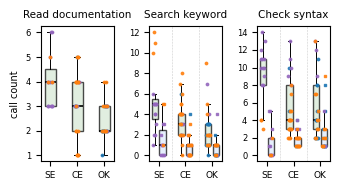

In [14]:
# ── Variant: endpoint columns, domains combined, coloured by domain ───────────
# Depends on df_tu, _CAT_ORDER, _BOX_MAIN, _BOX_SEC, _rng from the preceding cell.

_SHOW_LEGEND_V2 = False   # set True to re-enable the bottom legend

_DOMAIN_COLORS = {"SRI": "#1f77b4", "traffic": "#ff7f0e", "pumpsystem": "#9467bd"}

_COLS_V2 = [
    ("read_hint_file",  None),
    ("search_hints",    "search_hints_no_matches"),
    ("check_syntax",    "check_syntax_no_errors"),
]
_COL_TITLES_V2 = {
    "read_hint_file": "Read documentation",
    "search_hints":   "Search keyword",
    "check_syntax":   "Check syntax",
}
_CAT_LABELS_V2 = {"SYNTAX": "SE", "COMPILATION": "CE", "CORRECT": "OK"}


def _panel_v2(ax, ep_main, ep2=None, *, show_ylabel=True):
    """Box + jittered strip for one endpoint column, all domains combined.

    Same paired-group layout as _group_panel; scatter coloured by domain.
    """
    paired = ep2 is not None
    CAT_GAP = 1.5 if paired else 1.0
    BOX_OFF = 0.22 if paired else 0.0
    BOX_W   = 0.35 if paired else 0.40

    centers  = [i * CAT_GAP for i in range(len(_CAT_ORDER))]
    pos_main = [c - BOX_OFF for c in centers]
    pos_sec  = [c + BOX_OFF for c in centers] if paired else None

    def _bplot(positions, series_list, facecolor):
        ax.boxplot(series_list, positions=positions, widths=BOX_W,
                   patch_artist=True,
                   boxprops=dict(facecolor=facecolor, alpha=0.7),
                   medianprops=dict(color="black", linewidth=1.2),
                   whiskerprops=dict(linewidth=0.7),
                   capprops=dict(linewidth=0.7),
                   flierprops=dict(marker=""))

    _bplot(pos_main,
           [df_tu.loc[df_tu["classification"] == c, ep_main].dropna().values
            for c in _CAT_ORDER],
           _BOX_MAIN)
    if paired:
        _bplot(pos_sec,
               [df_tu.loc[df_tu["classification"] == c, ep2].dropna().values
                for c in _CAT_ORDER],
               _BOX_SEC)

    for i, cat in enumerate(_CAT_ORDER):
        cat_rows = df_tu[df_tu["classification"] == cat]
        for domain, grp in cat_rows.groupby("domain"):
            color = _DOMAIN_COLORS[domain]
            vals = grp[ep_main].dropna().values
            if len(vals):
                jitter = _rng.uniform(-0.10, 0.10, size=len(vals))
                ax.scatter(pos_main[i] + jitter, vals,
                           color=color, s=3, alpha=0.85, zorder=3, marker="o")
            if paired:
                vals2 = grp[ep2].dropna().values
                if len(vals2):
                    jitter2 = _rng.uniform(-0.10, 0.10, size=len(vals2))
                    ax.scatter(pos_sec[i] + jitter2, vals2,
                               color=color, s=3, alpha=0.85, zorder=3, marker="s")

    if paired:
        for j in range(len(_CAT_ORDER) - 1):
            ax.axvline((centers[j] + centers[j + 1]) / 2,
                       color="grey", linewidth=0.4, linestyle="--", alpha=0.4)

    ax.set_xticks(centers)
    ax.set_xticklabels([_CAT_LABELS_V2[c] for c in _CAT_ORDER], fontsize=6.5,
                       rotation=0, ha="center")
    ax.tick_params(axis="y", labelsize=6)
    right_edge = (pos_sec[-1] if paired else pos_main[-1]) + BOX_W / 2 + 0.15
    ax.set_xlim(pos_main[0] - BOX_W / 2 - 0.15, right_edge)
    if show_ylabel:
        ax.set_ylabel("call count", fontsize=7)


fig2, axes2 = plt.subplots(1, len(_COLS_V2), figsize=(3.5, 2.0))

for col, (ep_main, ep2) in enumerate(_COLS_V2):
    ax = axes2[col]
    _panel_v2(ax, ep_main, ep2, show_ylabel=(col == 0))
    ax.set_title(_COL_TITLES_V2[ep_main], fontsize=7.5)

if _SHOW_LEGEND_V2:
    _dom_handles = [
        mpatches.Patch(color=_DOMAIN_COLORS[d], label=_DOMAIN_LABELS[d])
        for d in _DOMAIN_ORDER
    ]
    _box_handles2 = [
        mpatches.Patch(facecolor=_BOX_MAIN, edgecolor="grey", label="calls (○)"),
        mpatches.Patch(facecolor=_BOX_SEC,  edgecolor="grey", label="no errors/matches (□)"),
    ]
    fig2.legend(handles=_dom_handles + _box_handles2,
                loc="lower center", bbox_to_anchor=(0.5, 0),
                ncol=5, fontsize=6, framealpha=0.9,
                handlelength=1.2, handleheight=0.8, columnspacing=0.8)

plt.tight_layout(rect=[0, 0.16 if _SHOW_LEGEND_V2 else 0, 1, 1])
plt.savefig("figures_tooluse_v2.pdf", bbox_inches="tight")
plt.show()


In [15]:
# ── Raw merged tool-use data ──────────────────────────────────────────────────
_display_cols = [
    "llm", "domain", "requirement", "attempt", "classification",
    *[c for c in df_tu.columns
      if c not in {"llm", "domain", "requirement", "attempt",
                   "classification", "read_hint_file_params"}],
]

with pd.option_context("display.max_rows", None, "display.max_columns", None,
                       "display.width", None):
    display(
        df_tu[_display_cols]
        .sort_values(["domain", "requirement", "attempt"])
        .reset_index(drop=True)
    )

# read_hint_file_params separately (contains dicts)
print("\nread_hint_file_params:")
display(
    df_tu[["domain", "requirement", "attempt", "classification", "read_hint_file_params"]]
    .sort_values(["domain", "requirement", "attempt"])
    .reset_index(drop=True)
)


,llm,domain,requirement,attempt,classification,get_coding_instructions,read_hint_file,check_syntax,search_hints,search_hints_no_matches,check_syntax_no_errors,list_CRML_resource_files
0,qwen3.5_27b,SRI,speed1,1,CORRECT,1,3,8,1,0,5,0
1,qwen3.5_27b,SRI,speed1,2,CORRECT,1,3,4,3,1,2,0
2,qwen3.5_27b,SRI,speed1,3,CORRECT,1,3,8,2,0,3,0
3,qwen3.5_27b,SRI,speed1,4,CORRECT,1,2,5,1,0,2,0
4,qwen3.5_27b,SRI,speed1,5,COMPILATION,1,3,10,3,1,4,0
5,qwen3.5_27b,SRI,temp1,1,COMPILATION,1,3,5,6,4,1,0
6,qwen3.5_27b,SRI,temp1,2,CORRECT,1,2,2,3,1,1,0
7,qwen3.5_27b,SRI,temp1,3,CORRECT,1,1,4,0,0,1,0
8,qwen3.5_27b,SRI,temp1,4,CORRECT,1,3,11,3,2,8,0
9,qwen3.5_27b,SRI,temp1,5,CORRECT,1,2,4,1,0,1,0



read_hint_file_params:


,domain,requirement,attempt,classification,read_hint_file_params
0,SRI,speed1,1,CORRECT,"{'form_l_library.md': 2, 'class_type.md': 1}"
1,SRI,speed1,2,CORRECT,"{'form_l_library.md': 2, 'class_type.md': 1}"
2,SRI,speed1,3,CORRECT,"{'form_l_library.md': 2, 'class_type.md': 1}"
3,SRI,speed1,4,CORRECT,"{'form_l_library.md': 1, 'class_type.md': 1}"
4,SRI,speed1,5,COMPILATION,"{'form_l_library.md': 1, 'class_type.md': 1, '..."
...,...,...,...,...,...
60,traffic,r6,1,COMPILATION,"{'form_l_library.md': 2, 'period_periods_types..."
61,traffic,r6,2,COMPILATION,"{'form_l_library.md': 1, 'clock_type.md': 1}"
62,traffic,r6,3,SYNTAX,"{'form_l_library.md': 1, 'clock_type.md': 2, '..."
63,traffic,r6,4,SYNTAX,"{'form_l_library.md': 1, 'clock_type.md': 1, '..."
